# Notebook 05 — Eye State Classification with MobileNetV2

## Objective

Train a transfer-learning model for the dedicated eye-state task:

- `Closed`
- `Open`



 
- Load ImageNet-pretrained MobileNetV2.
- Freeze the pretrained convolutional base.
- Train new classification layers.

Fine-tuning
- Unfreeze only the upper portion of MobileNetV2.
- Use a much smaller learning rate.
- Continue training carefully to adapt the pretrained features to eye-state recognition.




In [1]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

STAGE_1_EPOCHS = 15
STAGE_2_EPOCHS = 15

tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

EYE_DATASET_DIR = PROJECT_ROOT / "eye_dataset"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Eye dataset:", EYE_DATASET_DIR)


TensorFlow version: 2.21.0
Project root: d:\driver-drowsiness-detection
Eye dataset: d:\driver-drowsiness-detection\eye_dataset


## 1. Load the eye dataset


In [2]:
CLASS_NAMES = ["Closed", "Open"]

train_dir = EYE_DATASET_DIR / "train"
val_dir = EYE_DATASET_DIR / "validation"
test_dir = EYE_DATASET_DIR / "test"

for directory in [train_dir, val_dir, test_dir]:
    if not directory.exists():
        raise FileNotFoundError(f"Missing dataset directory: {directory}")

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# IMPORTANT:
# Capture class names BEFORE prefetch().
# A PrefetchDataset does not expose the class_names attribute.
detected_class_names = train_ds.class_names

if detected_class_names != CLASS_NAMES:
    raise ValueError(
        f"Unexpected class mapping. Expected {CLASS_NAMES}, "
        f"but found {detected_class_names}"
    )

print("Class names:", detected_class_names)


Found 1026 files belonging to 2 classes.
Found 212 files belonging to 2 classes.
Found 214 files belonging to 2 classes.
Class names: ['Closed', 'Open']


## 2. Dataset performance pipeline




In [3]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("✓ Dataset pipelines prepared.")
print("Class mapping:", CLASS_NAMES)


✓ Dataset pipelines prepared.
Class mapping: ['Closed', 'Open']


## 3. Training-only augmentation



In [4]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.08),
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(0.08),
    ],
    name="training_augmentation"
)

print("Training augmentation configured.")


Training augmentation configured.


## 4. Load MobileNetV2




In [5]:
base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 layers:", len(base_model.layers))
print("Trainable base layers:", sum(layer.trainable for layer in base_model.layers))


MobileNetV2 layers: 154
Trainable base layers: 0


## 5. Build the transfer-learning model


In [6]:
inputs = keras.Input(shape=(*IMG_SIZE, 3))

x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)

# Keep the frozen MobileNetV2 BatchNormalization layers in inference mode.
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="eye_mobilenetv2")

model.summary()


Model: "eye_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Stage 1 — Train the classification head

The MobileNetV2 base remains frozen.


In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

stage1_path = MODEL_DIR / "eye_mobilenetv2_stage1_best.keras"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        stage1_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

stage1_start = time.time()

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE_1_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1
)

stage1_seconds = time.time() - stage1_start

print(f"Stage 1 training time: {stage1_seconds / 60:.2f} minutes")


Epoch 1/15


d:\driver-drowsiness-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9201 - loss: 0.2040
Epoch 1: val_loss improved from None to 0.02392, saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_stage1_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 779ms/step - accuracy: 0.9201 - loss: 0.2040 - val_accuracy: 0.9906 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 2/15
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.9863 - loss: 0.0452
Epoch 2: val_loss improved from 0.02392 to 0.01088, saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_stage1_best.keras

Epoch 2: finished saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_stage1_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 822ms/step - accuracy: 0.9864 - loss: 0.0451 - val_accuracy: 1.0000 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 

## 7. Stage 2 — Fine-tune upper MobileNetV2 layers

Only the upper portion of MobileNetV2 is unfrozen.

BatchNormalization layers remain frozen to improve fine-tuning stability on this relatively small dataset.


In [8]:
# Load the best Stage 1 model.
model = keras.models.load_model(stage1_path)

# Find the MobileNetV2 base.
base_model_loaded = None

for layer in model.layers:
    if isinstance(layer, keras.Model) and "mobilenetv2" in layer.name.lower():
        base_model_loaded = layer
        break

if base_model_loaded is None:
    raise RuntimeError("Could not locate the MobileNetV2 base model.")

base_model_loaded.trainable = True

# Fine-tune only the top 30 layers.
FINE_TUNE_FROM = max(0, len(base_model_loaded.layers) - 30)

for i, layer in enumerate(base_model_loaded.layers):
    layer.trainable = i >= FINE_TUNE_FROM

# Keep BatchNormalization layers frozen.
for layer in base_model_loaded.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_base = sum(
    1 for layer in base_model_loaded.layers if layer.trainable
)

print("MobileNetV2 total layers:", len(base_model_loaded.layers))
print("Fine-tuning from layer index:", FINE_TUNE_FROM)
print("Trainable MobileNetV2 layers:", trainable_base)


MobileNetV2 total layers: 154
Fine-tuning from layer index: 124
Trainable MobileNetV2 layers: 19


In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model_path = MODEL_DIR / "eye_mobilenetv2_best.keras"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        final_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

stage2_start = time.time()

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE_2_EPOCHS,
    callbacks=stage2_callbacks,
    verbose=1
)

stage2_seconds = time.time() - stage2_start

print(f"Stage 2 training time: {stage2_seconds / 60:.2f} minutes")


Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9932 - loss: 0.0166
Epoch 1: val_loss improved from None to 0.00388, saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_best.keras

Epoch 1: finished saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 765ms/step - accuracy: 0.9932 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 0.0039 - learning_rate: 1.0000e-05
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.9961 - loss: 0.0096
Epoch 2: val_loss improved from 0.00388 to 0.00289, saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_best.keras

Epoch 2: finished saving model to d:\driver-drowsiness-detection\models\eye_mobilenetv2_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 676ms/step - accuracy: 0.9961 - loss: 0.0096 - val_accuracy: 1.0000 - val_loss: 0.0029 - learning_rate: 1.0000e-05
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.9942 - 

## 8. Combine training histories and plot curves


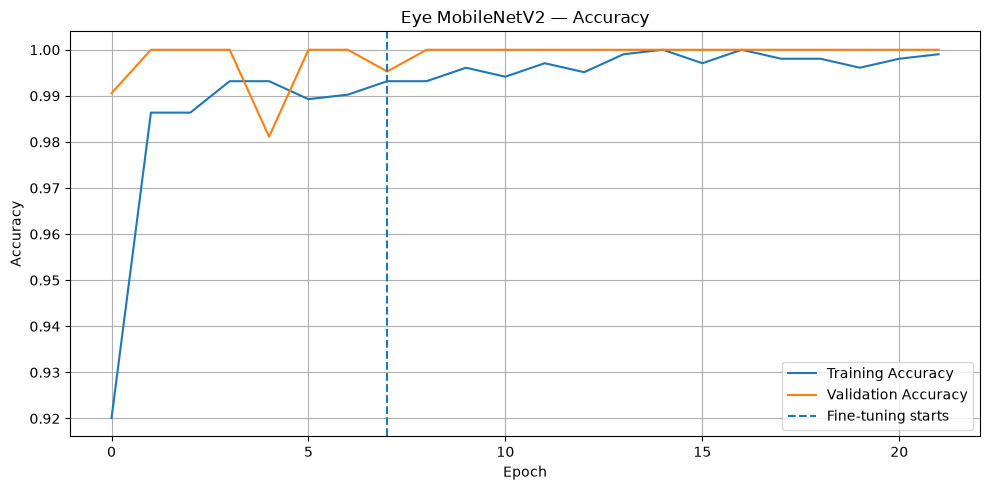

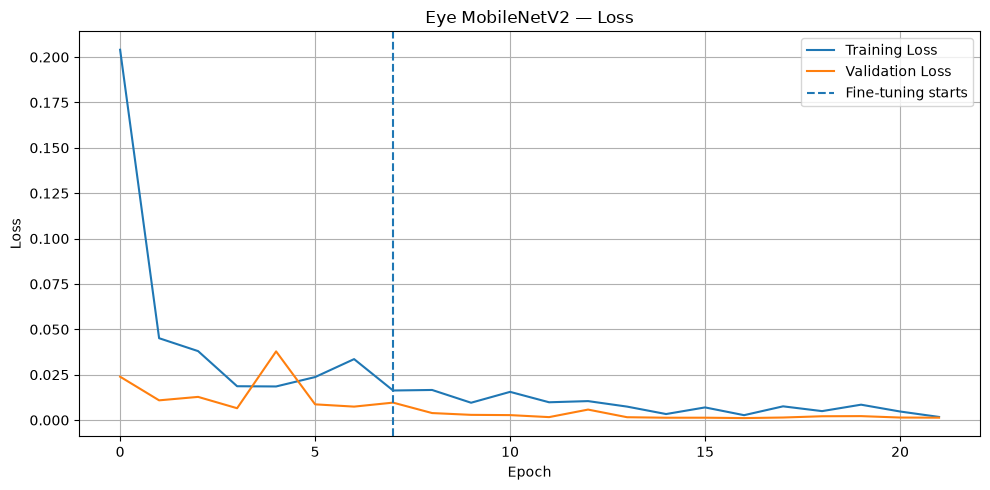

Saved:
d:\driver-drowsiness-detection\outputs\eye_mobilenetv2_accuracy.png
d:\driver-drowsiness-detection\outputs\eye_mobilenetv2_loss.png


In [10]:
history_combined = {}

for key in history_stage1.history:
    history_combined[key] = (
        history_stage1.history[key] +
        history_stage2.history.get(key, [])
    )

history_df = pd.DataFrame(history_combined)

stage1_last_epoch = len(history_stage1.history["accuracy"])

fig = plt.figure(figsize=(10, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    stage1_last_epoch - 1,
    linestyle="--",
    label="Fine-tuning starts"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Eye MobileNetV2 — Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_plot = OUTPUT_DIR / "eye_mobilenetv2_accuracy.png"
plt.savefig(accuracy_plot, dpi=150)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.axvline(
    stage1_last_epoch - 1,
    linestyle="--",
    label="Fine-tuning starts"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Eye MobileNetV2 — Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot = OUTPUT_DIR / "eye_mobilenetv2_loss.png"
plt.savefig(loss_plot, dpi=150)
plt.show()

print("Saved:")
print(accuracy_plot)
print(loss_plot)


## 9. Evaluate on the unseen test set



In [11]:
best_model = keras.models.load_model(final_model_path)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 686ms/step - accuracy: 1.0000 - loss: 1.5760e-04
Test loss: 0.0002
Test accuracy: 1.0000


In [12]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Closed     1.0000    1.0000    1.0000       102
        Open     1.0000    1.0000    1.0000       112

    accuracy                         1.0000       214
   macro avg     1.0000    1.0000    1.0000       214
weighted avg     1.0000    1.0000    1.0000       214



## 10. Confusion matrix


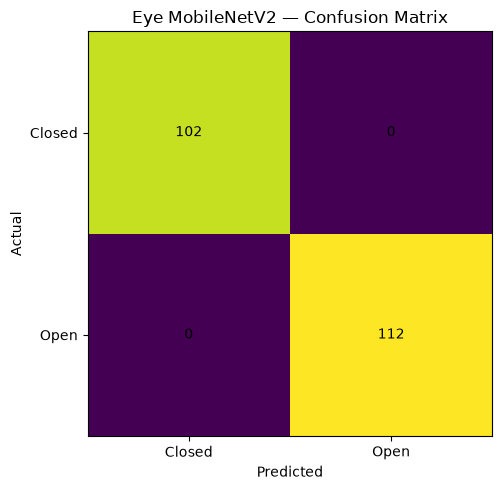

Saved: d:\driver-drowsiness-detection\outputs\eye_mobilenetv2_confusion_matrix.png


In [13]:
cm = confusion_matrix(y_true, y_pred)

fig = plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Eye MobileNetV2 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = OUTPUT_DIR / "eye_mobilenetv2_confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print("Saved:", cm_path)


## 11. Confidence analysis

Confidence will be used later by the decision-fusion layer.

The final application should be able to reject weak evidence rather than forcing a state.


In [14]:
max_confidence = np.max(y_prob, axis=1)

confidence_summary = {
    "mean_confidence": float(np.mean(max_confidence)),
    "median_confidence": float(np.median(max_confidence)),
    "minimum_confidence": float(np.min(max_confidence)),
    "maximum_confidence": float(np.max(max_confidence))
}

print(json.dumps(confidence_summary, indent=2))


{
  "mean_confidence": 0.9998427033424377,
  "median_confidence": 0.9999996423721313,
  "minimum_confidence": 0.993480920791626,
  "maximum_confidence": 1.0
}


## 12. Save metrics


In [15]:
total_training_seconds = stage1_seconds + stage2_seconds

metrics = {
    "model": "Eye MobileNetV2",
    "classes": CLASS_NAMES,
    "image_size": list(IMG_SIZE),
    "stage_1_epochs_requested": STAGE_1_EPOCHS,
    "stage_1_epochs_completed": len(history_stage1.history["loss"]),
    "stage_2_epochs_requested": STAGE_2_EPOCHS,
    "stage_2_epochs_completed": len(history_stage2.history["loss"]),
    "stage_1_training_minutes": round(stage1_seconds / 60, 3),
    "stage_2_training_minutes": round(stage2_seconds / 60, 3),
    "total_training_minutes": round(total_training_seconds / 60, 3),
    "test_accuracy": round(float(accuracy), 6),
    "test_precision_weighted": round(float(precision), 6),
    "test_recall_weighted": round(float(recall), 6),
    "test_f1_weighted": round(float(f1), 6),
    "mean_prediction_confidence": round(float(np.mean(max_confidence)), 6),
    "median_prediction_confidence": round(float(np.median(max_confidence)), 6)
}

metrics_path = OUTPUT_DIR / "eye_mobilenetv2_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2))

print(json.dumps(metrics, indent=2))
print("\nSaved:", metrics_path)
print("Best model:", final_model_path)


{
  "model": "Eye MobileNetV2",
  "classes": [
    "Closed",
    "Open"
  ],
  "image_size": [
    224,
    224
  ],
  "stage_1_epochs_requested": 15,
  "stage_1_epochs_completed": 8,
  "stage_2_epochs_requested": 15,
  "stage_2_epochs_completed": 14,
  "stage_1_training_minutes": 3.755,
  "stage_2_training_minutes": 8.042,
  "total_training_minutes": 11.797,
  "test_accuracy": 1.0,
  "test_precision_weighted": 1.0,
  "test_recall_weighted": 1.0,
  "test_f1_weighted": 1.0,
  "mean_prediction_confidence": 0.999843,
  "median_prediction_confidence": 1.0
}

Saved: d:\driver-drowsiness-detection\outputs\eye_mobilenetv2_metrics.json
Best model: d:\driver-drowsiness-detection\models\eye_mobilenetv2_best.keras
